In [4]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [2]:
ENV_PATH = r"C:\Users\D\Python scripts\Innopolis 2026\AI architecht\.env"

# Загружаем данные

In [9]:
query = """
    SELECT
        f.rental_duration,
        f.rental_rate,
        f.replacement_cost,
        f.length AS film_length,
        p.amount
    FROM payment p
    JOIN rental r ON p.rental_id = r.rental_id
    JOIN inventory i ON r.inventory_id = i.inventory_id
    JOIN film f ON i.film_id = f.film_id
"""

load_dotenv(ENV_PATH )
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")

conn_url = f"postgresql://{user}:{password}@{host}:{port}/{database}"
engine = create_engine(conn_url)

df = pd.read_sql(query, engine)

In [10]:
df.head()

,rental_duration,rental_rate,replacement_cost,film_length,amount
0,6,4.99,19.99,153,7.99
1,5,0.99,15.99,130,1.99
2,3,4.99,9.99,138,7.99
3,5,2.99,11.99,100,2.99
4,6,4.99,16.99,165,7.99


Попытаемся предсказать сумму платежа за прокат на основе других переменных

amount - целевая переменная

# 1. Изучаем характеристики целевой переменной

In [12]:
df['amount'].describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
amount,14596.0,4.200606,2.368946,0.0,2.99,3.99,4.99,11.99


In [17]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

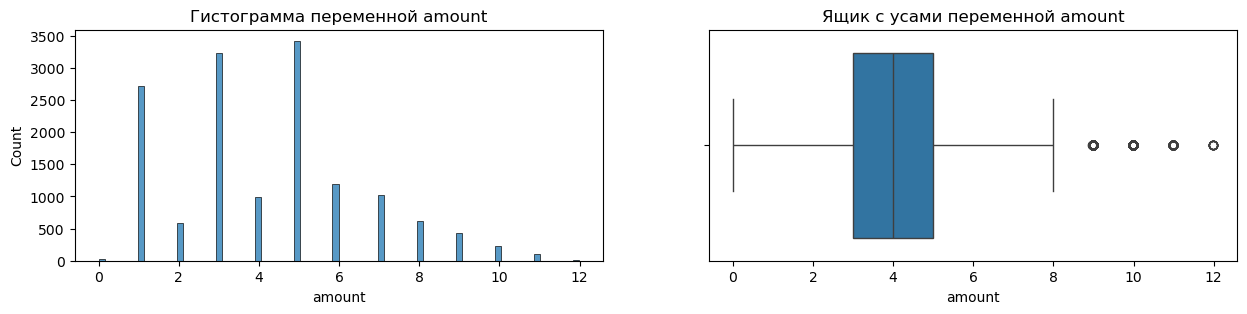

In [18]:
visualize_distribution(df, variable = "amount")

# 2. Чистим данные

In [46]:
# Убираем из целевой переменной нули
df = df[df["amount"] != 0]

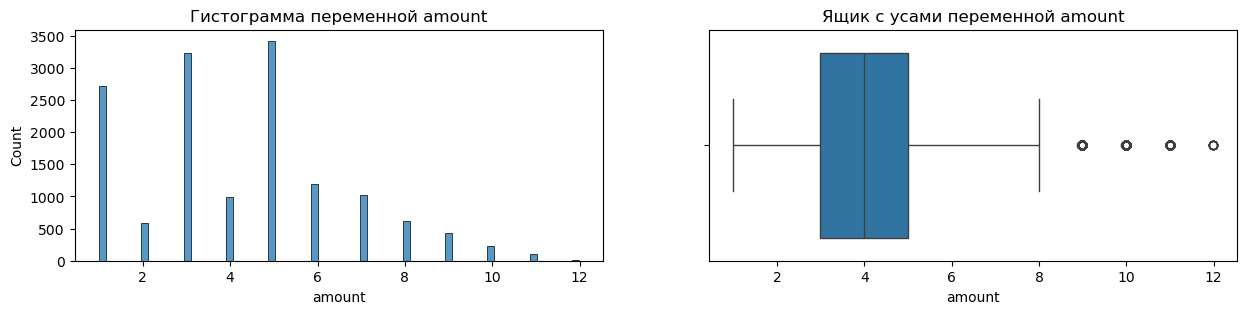

In [47]:
visualize_distribution(df, variable = "amount")

# 3. Обучим модели линейной регрессии

#### Простая модель $amount_i = w_0 + w_1 \cdot rental\_duration_i$

In [48]:
# Определяем целевую переменную и набор признаков
target_col = ["amount"]
features_col = ["rental_duration"]

In [49]:
# Делим выборку на обучающую и тестовую
X = df[features_col]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
# random_state нужен, чтобы впоследствии воспроизвести состав train и test выборок

In [55]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

In [50]:
# Инициализуем и обучаем модель линейной регрессии
lin_reg = LinearRegression()    # Инициализация
lin_reg.fit(X_train, y_train)   # Обучение модели

LinearRegression()

In [56]:
def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [51]:
# Делаем предсказания на тестовой выборке
y_pred = lin_reg.predict(X_test)

In [57]:
def get_predictions(model, X_test):
    return model.predict(X_test)

In [68]:
def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

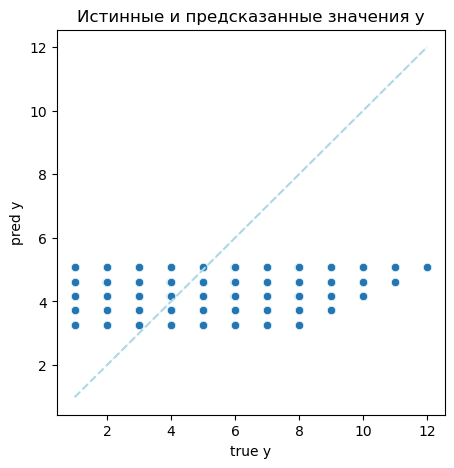

In [53]:
# Визуализуем предсказание на тестовой выборке
visualize_prediction(y_test, y_pred)

In [54]:
# Считаем метрики качества на тестовой выборке
show_metrics(y_test, y_pred)

Среднее значение Y:  4.22537533790809
Среднеквадратическое отклонение Y:  2.3907762184928822
MSE:  5.236386896190262
RMSE:  2.2883152964987716
MAE:  1.8737749733872116
MAPE:  0.8508482015655517
R2:  0.08387681762941868


C:\Users\D\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
C:\Users\D\AppData\Local\Temp\ipykernel_2040\615285900.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Среднеквадратическое отклонение Y: ', np.std(y_true)[0])


#### Модель $amount_i = w_0 + w_1 \cdot rental\_duration_i + w_2 \cdot rental\_rate_i$

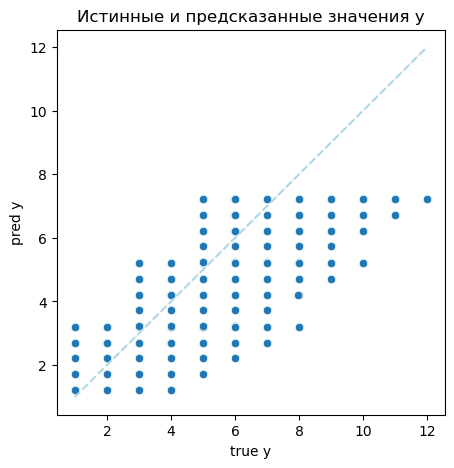

Среднее значение Y:  4.22537533790809
Среднеквадратическое отклонение Y:  2.3907762184928822
MSE:  2.473467615578452
RMSE:  1.5727261731078466
MAE:  1.2671036345247122
MAPE:  0.42389295928559323
R2:  0.5672586712179468


In [69]:
target_col = ["amount"]
features_col = ["rental_duration", "rental_rate"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Модель $amount_i = w_0 + w_1 \cdot rental\_duration_i + w_2 \cdot rental\_rate_i + w_3 \cdot replacement\_cost_i + w_4 \cdot film\_length_i$

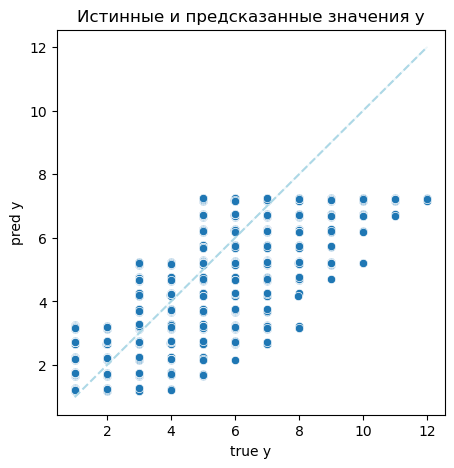

Среднее значение Y:  4.22537533790809
Среднеквадратическое отклонение Y:  2.3907762184928822
MSE:  2.4729656829094946
RMSE:  1.572566590930093
MAE:  1.2671665579464737
MAPE:  0.4244104785981251
R2:  0.5673464859961779


In [70]:
target_col = ["amount"]
features_col = ["rental_duration", "rental_rate", "replacement_cost", "film_length"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

# 4. Интерпретируем полученную модель

In [101]:
w0 = model.intercept_   # Забираем intercept
weights = model.coef_   # Забираем веса модели
features = model.feature_names_in_
pd.Series(dict(zip(features.tolist()+['intercept'], weights[0].tolist()+[w0[0]])))

rental_duration    -0.492447
rental_rate         1.003420
replacement_cost    0.004919
film_length        -0.000062
intercept           3.586846
dtype: float64

$\hat{amount} = 3.5868 - 0.4924 \cdot rental\_duration_i + 1.0034 \cdot rental\_rate_i + 0.0049 \cdot replacement\_cost_i - 0.00006 \cdot film\_length_i$

# 5. Повышаем качество модели

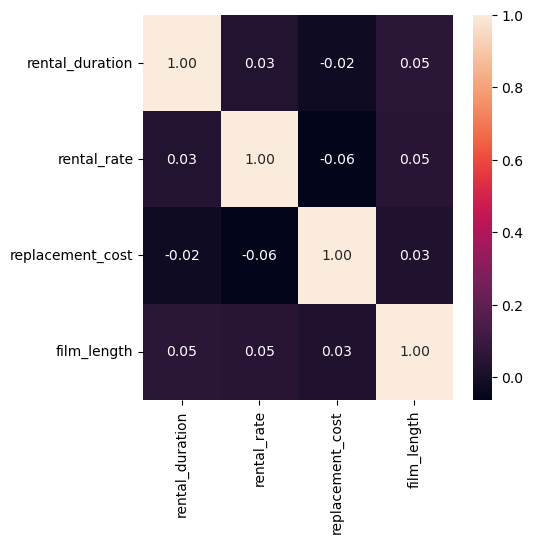

In [104]:
# Проверям переменные на мультиколлинеарность и убираем те, которые тесно скоррелированы
fig, ax = plt.subplots(1,1, figsize = (5,5))
sns.heatmap(df[features_col].corr(), annot = True, fmt='.2f')
plt.show()

Среди признаков нет тех, которые взаимно скоррелированы, следовательно, все они могут остаться в модели

# 6. Примеры форм зависимостей между Х и Y

Линейная зависимость

In [ ]:
x1 = data['rm'].values
y = data['medv'].values

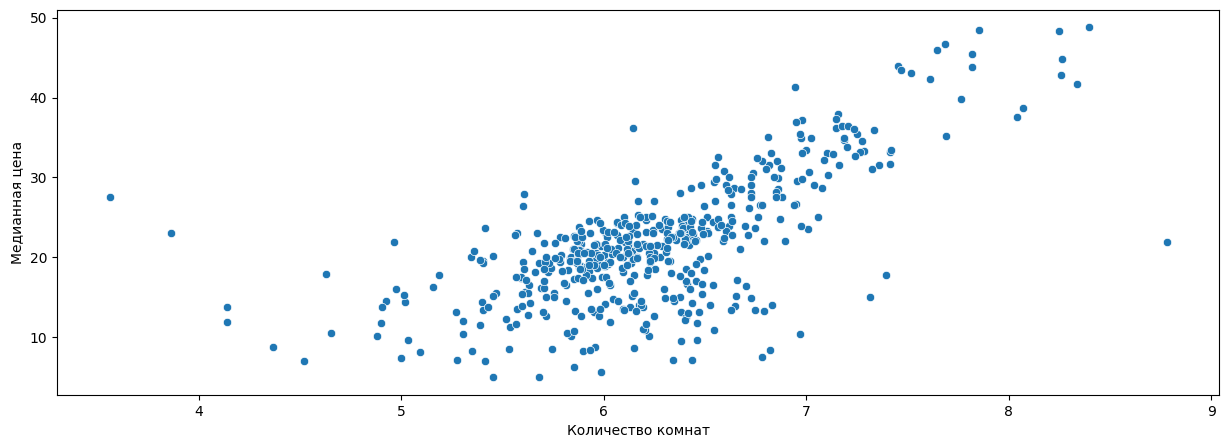

In [ ]:
plt.figure(figsize = (15,5))
sns.scatterplot(x = x1, y = y)
plt.xlabel('Количество комнат')
plt.ylabel('Медианная цена')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
reg1 = LinearRegression()
reg1.fit(x1.reshape(-1,1), y)
y_pred1 = reg1.predict(x1.reshape(-1,1))

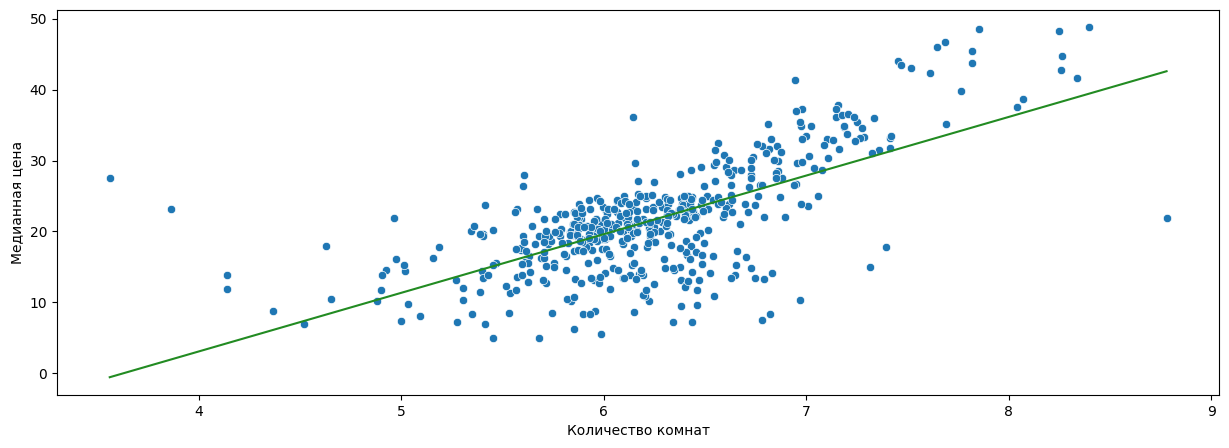

In [ ]:
plt.figure(figsize = (15,5))
sns.scatterplot(x = x1, y = y)
sns.lineplot(x = x1, y = y_pred1, c = 'forestgreen')
plt.xlabel('Количество комнат')
plt.ylabel('Медианная цена')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred1)),
print('RMSE: ', root_mean_squared_error(y, y_pred1))
print('MAE: ', mean_absolute_error(y, y_pred1))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred1))
print('R2: ', r2_score(y, y_pred1))

Среднее значение Y:  21.63591836734694
Среднеквадратическое отклонение Y:  7.857271146580544
MSE:  32.629908144716346
RMSE:  5.712259460556422
MAE:  4.1108370989454235
MAPE:  0.25054027888637187
R2:  0.4714666814451758


Логарифмическая зависимость

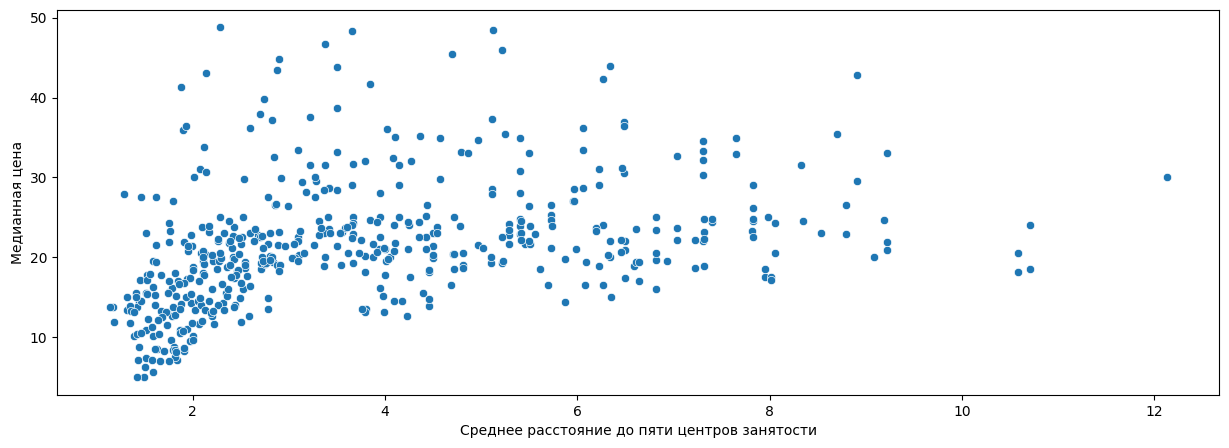

In [ ]:
plt.figure(figsize = (15,5))
x2 = data['dis'].values
sns.scatterplot(x = x2, y = y)
plt.xlabel('Среднее расстояние до пяти центров занятости')
plt.ylabel('Медианная цена')
plt.show()

In [ ]:
reg2 = LinearRegression()
reg2.fit(x2.reshape(-1,1), y)
y_pred2 = reg2.predict(x2.reshape(-1,1))

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred2)),
print('RMSE: ', root_mean_squared_error(y, y_pred2))
print('MAE: ', mean_absolute_error(y, y_pred2))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred2))
print('R2: ', r2_score(y, y_pred2))

Среднее значение Y:  21.63591836734694
Среднеквадратическое отклонение Y:  7.857271146580544
MSE:  53.33908718114265
RMSE:  7.303361361807497
MAE:  5.41767590610431
MAPE:  0.2959600431178685
R2:  0.1360231652659628


In [ ]:
x3 = np.log(x2)

reg3 = LinearRegression()
reg3.fit(x3.reshape(-1,1), y)
y_pred3 = reg3.predict(x3.reshape(-1,1))

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred3)),
print('RMSE: ', root_mean_squared_error(y, y_pred3))
print('MAE: ', mean_absolute_error(y, y_pred3))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred3))
print('R2: ', r2_score(y, y_pred3))

Среднее значение Y:  21.63591836734694
Среднеквадратическое отклонение Y:  7.857271146580544
MSE:  49.67319526363976
RMSE:  7.047921343462891
MAE:  5.200724925073205
MAPE:  0.2761980430097869
R2:  0.19540261592294694


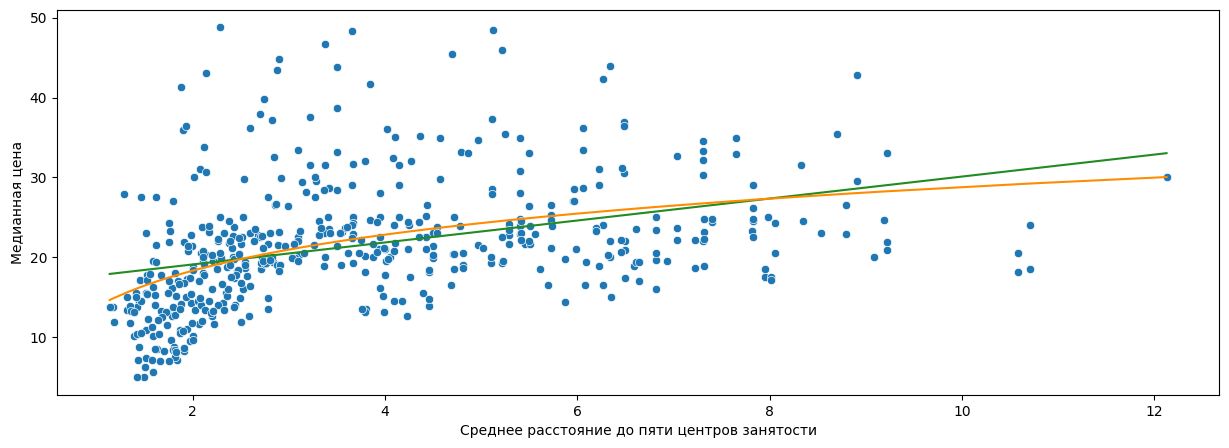

In [ ]:
plt.figure(figsize = (15,5))
sns.scatterplot(x = x2, y = y)
sns.lineplot(x = x2, y = y_pred2, c = 'forestgreen')
sns.lineplot(x = x2, y = y_pred3, c = 'darkorange')
plt.xlabel('Среднее расстояние до пяти центров занятости')
plt.ylabel('Медианная цена')
plt.show()

Попробуем полином второй степени

In [ ]:
X = np.vstack([x2, x2**2]).T
reg6 = LinearRegression()
reg6.fit(X, y)
y_pred6 = reg6.predict(X)

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred6)),
print('RMSE: ', root_mean_squared_error(y, y_pred6))
print('MAE: ', mean_absolute_error(y, y_pred6))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred6))
print('R2: ', r2_score(y, y_pred6))

Среднее значение Y:  21.63591836734694
Среднеквадратическое отклонение Y:  7.857271146580544
MSE:  48.74802974757209
RMSE:  6.981978927751937
MAE:  5.146112691046246
MAPE:  0.27166351338718514
R2:  0.2103882787158382


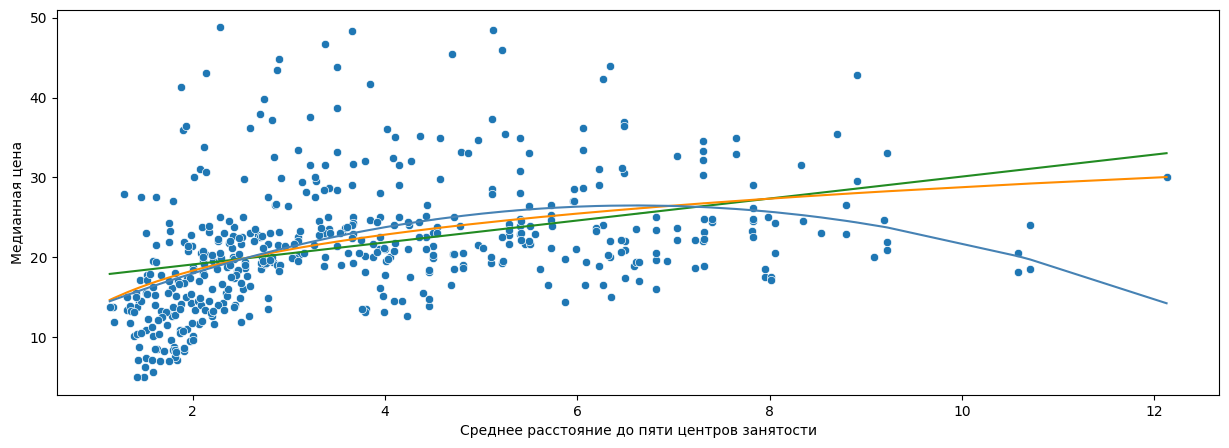

In [ ]:
plt.figure(figsize = (15,5))
sns.scatterplot(x = x2, y = y)
sns.lineplot(x = x2, y = y_pred2, c = 'forestgreen')
sns.lineplot(x = x2, y = y_pred3, c = 'darkorange')
sns.lineplot(x = x2, y = y_pred6, c = 'steelblue')
plt.xlabel('Среднее расстояние до пяти центров занятости')
plt.ylabel('Медианная цена')
plt.show()

Гипербола

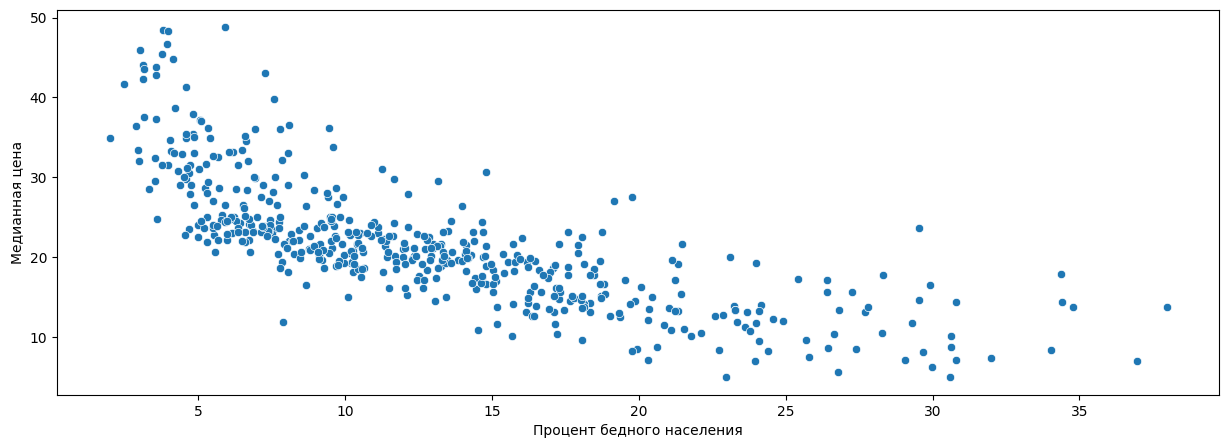

In [ ]:
plt.figure(figsize = (15,5))
x4 = data['lstat'].values
sns.scatterplot(x = x4, y = y)
plt.xlabel('Процент бедного населения')
plt.ylabel('Медианная цена')
plt.show()

In [ ]:
reg4 = LinearRegression()
reg4.fit(x4.reshape(-1,1), y)
y_pred4 = reg4.predict(x4.reshape(-1,1))

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred4)),
print('RMSE: ', root_mean_squared_error(y, y_pred4))
print('MAE: ', mean_absolute_error(y, y_pred4))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred4))
print('R2: ', r2_score(y, y_pred4))

Среднее значение Y:  21.63591836734694
Среднеквадратическое отклонение Y:  7.857271146580544
MSE:  26.092834440020287
RMSE:  5.108114568020209
MAE:  3.7960338449538065
MAPE:  0.19241666660032652
R2:  0.57735301258215


In [ ]:
x5 = 1/x4

reg5 = LinearRegression()
reg5.fit(x5.reshape(-1,1), y)
y_pred5 = reg5.predict(x5.reshape(-1,1))

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred5)),
print('RMSE: ', root_mean_squared_error(y, y_pred5))
print('MAE: ', mean_absolute_error(y, y_pred5))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred5))
print('R2: ', r2_score(y, y_pred5))

Среднее значение Y:  21.63591836734694
Среднеквадратическое отклонение Y:  7.857271146580544
MSE:  22.922084808850343
RMSE:  4.787701411831187
MAE:  3.5488576840562964
MAPE:  0.19570050553750556
R2:  0.6287122385240747


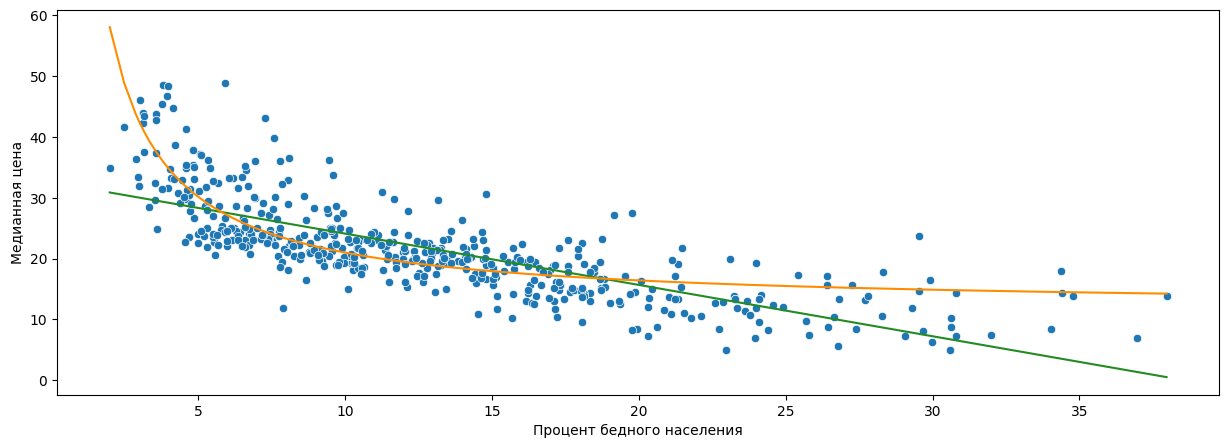

In [ ]:
plt.figure(figsize = (15,5))
sns.scatterplot(x = x4, y = y)
sns.lineplot(x = x4, y = y_pred4, c = 'forestgreen')
sns.lineplot(x = x4, y = y_pred5, c = 'darkorange')
plt.xlabel('Процент бедного населения')
plt.ylabel('Медианная цена')
plt.show()

# 7. Множественная регрессия

In [ ]:
data[['rm', 'dis', 'lstat']].corr()

,rm,dis,lstat
rm,1.000000,0.245789,-0.610369
dis,0.245789,1.000000,-0.536493
lstat,-0.610369,-0.536493,1.000000


In [116]:
data['dis2'] = data['dis']**2
data['lstat_inv'] = 1/data['lstat']
X = data[['rm', 'dis', 'dis2', 'lstat_inv', 'chas']]
y = data['medv']

reg_mult = LinearRegression()
reg_mult.fit(X, y)
y_pred_mult = reg_mult.predict(X)

print('Среднее значение Y: ', np.mean(y))
print('Среднеквадратическое отклонение Y: ', np.std(y))
print('MSE: ', mean_squared_error(y, y_pred_mult)),
print('RMSE: ', root_mean_squared_error(y, y_pred_mult))
print('MAE: ', mean_absolute_error(y, y_pred_mult))
print('MAPE: ', mean_absolute_percentage_error(y, y_pred_mult))
print('R2: ', r2_score(y, y_pred_mult))

Среднее значение Y:  22.532806324110677
Среднеквадратическое отклонение Y:  9.188011545278206
MSE:  25.12857660444298
RMSE:  5.012841170877348
MAE:  3.5509709836832357
MAPE:  0.1906407762108409
R2:  0.7023370206074256


In [ ]:
import pandas as pd
pd.DataFrame(index = X.columns, data = reg_mult.coef_).T

,rm,dis,dis2,lstat_inv,chas
0,3.504818,1.651741,-0.157602,65.911847,1.813935


In [ ]:
65.91/7.3475 - 65.91/11.675

3.3250019489797182

In [ ]:
data['lstat'].describe()

,lstat
count,490.00000
mean,12.92402
std,7.08318
min,1.98000
25%,7.34750
50%,11.67500
75%,17.11750
max,37.97000


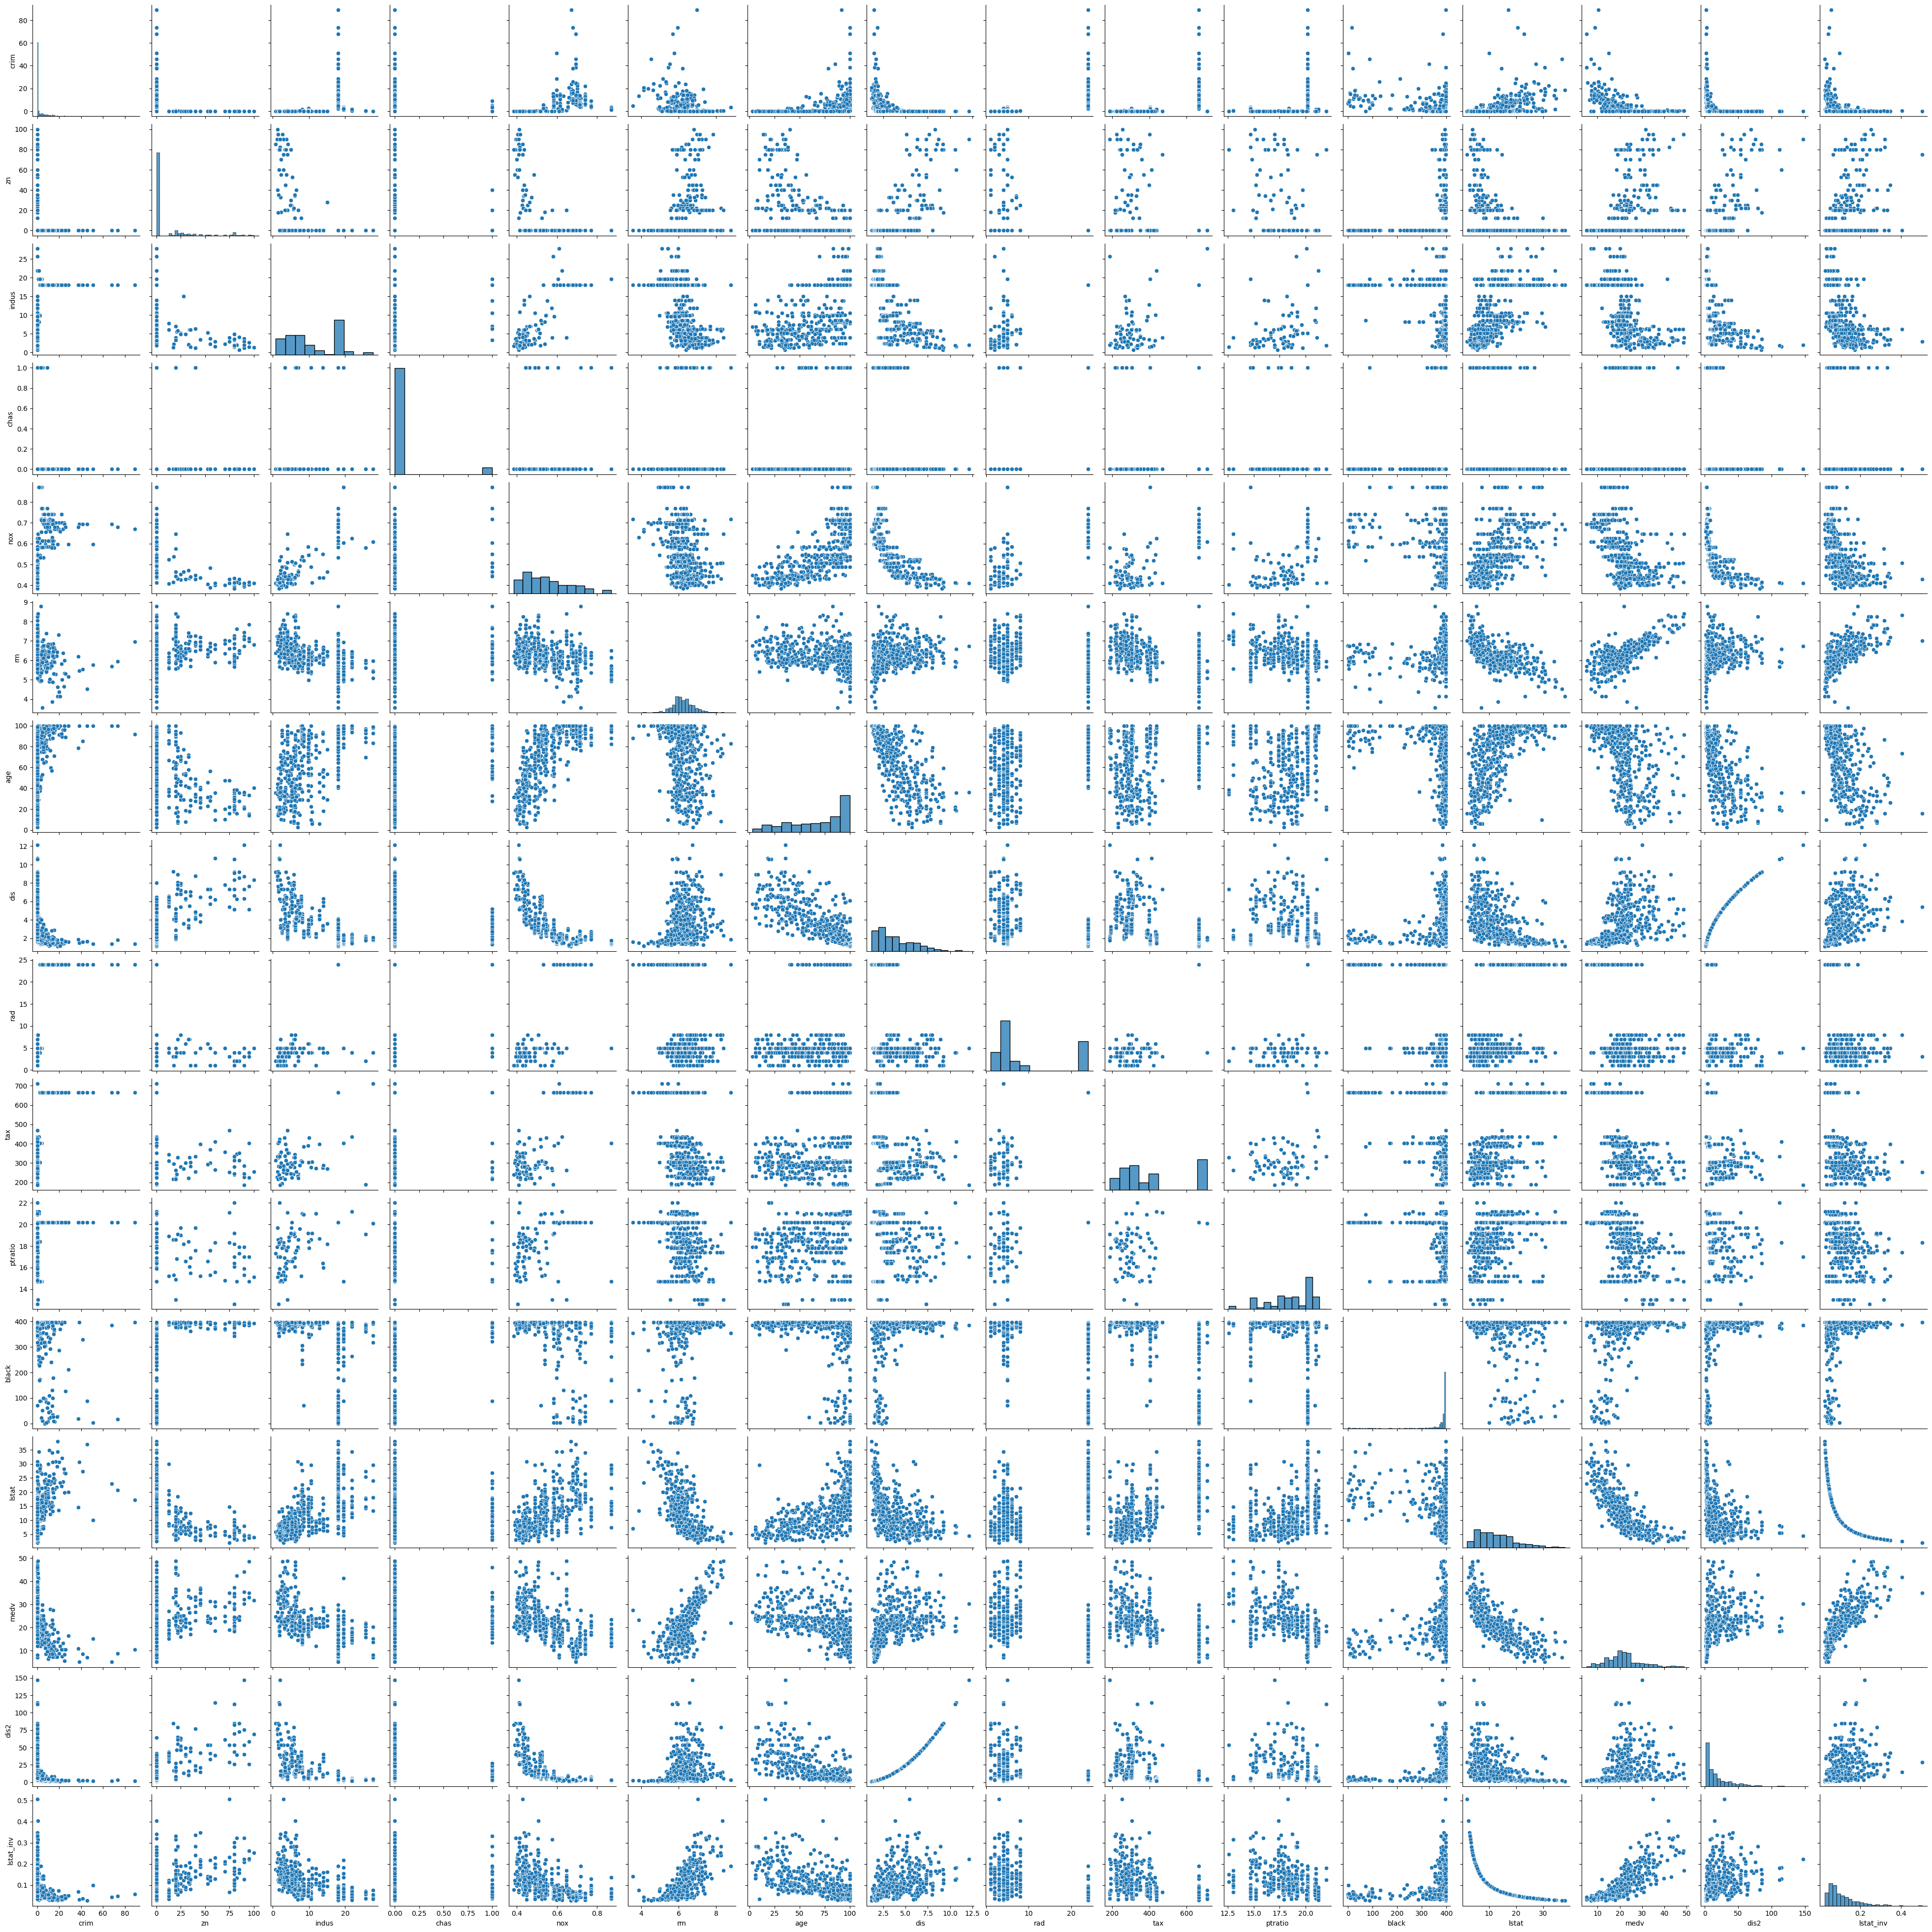

In [ ]:
sns.pairplot(data)

In [ ]:
data.shape

(490, 17)

In [ ]:
data['dis2'] = data['dis']**2
data['lstat_inv'] = 1/data['lstat']
data['rm5'] = data['rm']/5
X = data[['rm', 'dis', 'dis2', 'lstat_inv', 'chas']]
y = data['medv']

reg_mult = LinearRegression()
reg_mult.fit(X, y)
y_pred_mult = reg_mult.predict(X)
pd.DataFrame(index = X.columns, data = reg_mult.coef_).T

,rm,dis,dis2,lstat_inv,chas
0,3.504818,1.651741,-0.157602,65.911847,1.813935


# 8. Проверим устойчивость модели на разных выборках

In [ ]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

for random_state in range(0, 20, 2):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = random_state)

  reg = LinearRegression()
  reg.fit(X_train, y_train)
  y_pred = reg.predict(X_test)

  df1 = pd.DataFrame(
      {
          'MSE'  : mean_squared_error(y_test, y_pred),
          'RMSE' : root_mean_squared_error(y_test, y_pred),
          'MAE'  : mean_absolute_error(y_test, y_pred),
          'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
          'R2'   : r2_score(y_test, y_pred)
      },
      index = [random_state]
  )

  df2 = pd.DataFrame(
      index = X_train.columns,
      data = reg.coef_,
      columns = [random_state]
  )

  metrics_df = pd.concat([metrics_df, df1])
  coefs_df = pd.concat([coefs_df, df2], axis = 1)

         rm      dis      dis2  lstat_inv      chas
0  3.289334  1.61628 -0.152923  63.496685  1.402316
         rm       dis      dis2  lstat_inv      chas
0  2.373822  1.519441 -0.156911  75.072419  1.353449
         rm       dis      dis2  lstat_inv      chas
0  3.903961  1.911113 -0.182479  62.101368  1.414515
         rm       dis      dis2  lstat_inv      chas
0  3.354064  1.539611 -0.133865  63.404261  2.250408
         rm       dis      dis2  lstat_inv      chas
0  4.064237  1.645916 -0.154891  61.532843  1.703259
         rm       dis      dis2  lstat_inv      chas
0  3.472959  1.830168 -0.165569  66.184771  2.476494
         rm       dis      dis2  lstat_inv      chas
0  2.972551  2.523768 -0.236708  65.508371  1.866718
         rm       dis     dis2  lstat_inv      chas
0  3.213292  2.048649 -0.20147  64.949396  2.467738
         rm       dis      dis2  lstat_inv      chas
0  3.537105  1.655368 -0.169579  68.301755  1.412994
         rm      dis      dis2  lstat_inv      cha

# 9. Variance inflation factor

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data.sort_values(by = 'VIF', ascending = False).reset_index(drop = True)

In [ ]:
X = data[['crim', 'zn', 'chas', 'dis', 'rad', 'lstat']]
y = data['medv']

In [ ]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

for random_state in range(0, 20, 2):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = random_state)

  reg = LinearRegression()
  reg.fit(X_train, y_train)
  y_pred = reg.predict(X_test)

  df1 = pd.DataFrame(
      {
          'MSE'  : mean_squared_error(y_test, y_pred),
          'RMSE' : root_mean_squared_error(y_test, y_pred),
          'MAE'  : mean_absolute_error(y_test, y_pred),
          'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
          'R2'   : r2_score(y_test, y_pred)
      },
      index = [random_state]
  )

  df2 = pd.DataFrame(
      index = X_train.columns,
      data = reg.coef_,
      columns = [random_state]
  )

  metrics_df = pd.concat([metrics_df, df1])
  coefs_df = pd.concat([coefs_df, df2], axis = 1)

# 10. Lasso регрессия

In [ ]:
X = data.drop(columns = ['medv'])
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X_train, y_train)
y_pred = lasso_reg.predict(X_test)

In [ ]:
pd.DataFrame(
    data = {
        'MSE'  : mean_squared_error(y_test, y_pred),
        'RMSE' : root_mean_squared_error(y_test, y_pred),
        'MAE'  : mean_absolute_error(y_test, y_pred),
        'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
        'R2'   : r2_score(y_test, y_pred)
    },
      index = [0]
)

In [ ]:
pd.DataFrame(
      index = X_train.columns,
      data = lasso_reg.coef_
).T

# 11. Ridge регрессия

In [ ]:
X = data.drop(columns = ['medv'])
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

ridge_reg = Ridge(alpha=0.1)
ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)

In [ ]:
pd.DataFrame(
    data = {
        'MSE'  : mean_squared_error(y_test, y_pred),
        'RMSE' : root_mean_squared_error(y_test, y_pred),
        'MAE'  : mean_absolute_error(y_test, y_pred),
        'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
        'R2'   : r2_score(y_test, y_pred)
    },
      index = [0]
)

In [ ]:
pd.DataFrame(
      index = X_train.columns,
      data = ridge_reg.coef_
).T

# 12. Elastic Net регрессия

In [ ]:
from sklearn.linear_model import ElasticNet

X = data.drop(columns = ['medv'])
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

elnet_reg = ElasticNet(alpha=0.1)
elnet_reg.fit(X_train, y_train)
y_pred = elnet_reg.predict(X_test)